# Clasificación Automática de Modulaciones (AMC)
## Entrenamiento — CNN (representación Amplitud/Fase)

Este notebook entrena la misma arquitectura `CNNBaseline` de `../common/models.py` que usa
`../cnn/cnn.ipynb`, pero con la señal transformada a **Amplitud/Fase** (`to_amplitude_phase`
en `../common/data.py`) en vez de I/Q crudo. Como A/φ también tiene 2 canales, no hace falta
tocar la arquitectura — solo se transforma la entrada después del split. Sirve para comparar,
con la arquitectura fija, qué representación conviene más para el objetivo de liviandad del
proyecto (¿la misma CNN rinde igual o mejor con menos ambigüedad en la fase que con I/Q?).

Para probar otra profundidad/ancho, modificar `MODEL_KWARGS` más abajo y volver a correr el
notebook — la config usada queda guardada en `history.pkl` junto con el historial de
entrenamiento, así `comparacion.ipynb` puede reconstruir el modelo exacto antes de cargar los
pesos.


## 1. Imports y configuración

In [1]:
import sys
sys.path.insert(0, "..")

import pickle

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from common.models import CNNBaseline
from common.data import load_radioml_digital, split_dataset, make_loader, to_amplitude_phase, augment_rotate_iq
from common.train import train_model, SNRCurriculum, evaluate_by_snr, overall_accuracy, compute_cm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 256
EPOCHS = 50
PATIENCE = 10
SEED = 42

# Hiperparámetros de arquitectura — modificar acá para probar otra profundidad/ancho.
# No incluye n_classes (se completa con el dataset) para poder reusar la misma config
# sin importar cuántas clases tenga el split.
MODEL_KWARGS = dict(channels=(64, 64), kernel_size=3, fc_hidden=128, dropout=0.5)

# Entrenamiento por grupos de SNR (ver common/train.py::SNRCurriculum): se entrena primero con el
# grupo de SNR más alto y se van SUMANDO grupos más bajos (`group_size` niveles de SNR cada uno).
# Cada grupo se entrena hasta que la val accuracy (sobre todos los SNR) deja de mejorar durante
# `patience` épocas; si sumar un grupo no mejora la accuracy, se corta y se queda con los mejores
# pesos. En este modo `PATIENCE` no se usa y EPOCHS es solo un tope global de seguridad.
# Poner USE_CURRICULUM = False para entrenar con todos los SNR mezclados desde el inicio.
USE_CURRICULUM = True
CURRICULUM_KWARGS = dict(group_size=4, patience=3, min_gain=0.005, max_epochs_per_stage=15)
if USE_CURRICULUM:
    EPOCHS = 80

print(f"Usando dispositivo: {DEVICE}")

Usando dispositivo: cpu


## 2. Carga y preparación del dataset (I/Q → Amplitud/Fase)

In [2]:
X, y, snrs, le = load_radioml_digital(seed=SEED)
N_CLASSES = len(le.classes_)
print(f"Clases ({N_CLASSES}): {list(le.classes_)}")

(X_train, y_train, snr_train), (X_val, y_val, snr_val), (X_test, y_test, snr_test) = split_dataset(
    X, y, snrs, seed=SEED
)

# Data augmentation por rotación de constelación I/Q, solo en train (mismo criterio que
# cnn_preproc/) — se aplica ANTES de convertir a Amplitud/Fase, porque la rotación es una
# operación sobre I/Q (multiplicar por una matriz de rotación 2D no tiene sentido directo
# sobre A/φ).
X_train, y_train, snr_train = augment_rotate_iq(X_train, y_train, snr_train)

# Mismo split (misma semilla) que cnn/, lstm/, gru/, tcn/ — se transforma recién acá para
# que la comparación entre representaciones use exactamente las mismas señales de origen.
X_train = to_amplitude_phase(X_train)
X_val = to_amplitude_phase(X_val)
X_test = to_amplitude_phase(X_test)
print(f"Train (aumentado): {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

train_loader = make_loader(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True)
val_loader = make_loader(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False)

Clases (8): ['8PSK', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK']
Train (aumentado): (384000, 2, 128) | Val: (32000, 2, 128) | Test: (32000, 2, 128)


## 3. Entrenamiento — CNN (A/φ)

In [3]:
print("=== CNN (A/φ) ===")
print(f"Configuración: {MODEL_KWARGS}")
model = CNNBaseline(n_classes=N_CLASSES, **MODEL_KWARGS)
print(f"Parámetros: {model.count_parameters():,}")

curriculum = (SNRCurriculum(X_train, y_train, snr_train, batch_size=BATCH_SIZE, **CURRICULUM_KWARGS)
              if USE_CURRICULUM else None)

model, history = train_model(
    model, train_loader, val_loader,
    epochs=EPOCHS, patience=PATIENCE, device=DEVICE, curriculum=curriculum
)
history["model_kwargs"] = MODEL_KWARGS
history["curriculum"] = CURRICULUM_KWARGS if USE_CURRICULUM else None

torch.save(model.state_dict(), "cnn_ap.pt")
with open("history.pkl", "wb") as f:
    pickle.dump(history, f)

=== CNN (A/φ) ===
Configuración: {'channels': (64, 64), 'kernel_size': 3, 'fc_hidden': 128, 'dropout': 0.5}
Parámetros: 1,063,048
[curriculum] etapa 1/5: SNR >= 12 dB (76640 muestras)
Época   1 | SNR >=  12 dB | Train Loss: 1.1962 | Val Loss: 1.8680 | Val Acc: 0.3120 (mejor 0.3120)
Época   2 | SNR >=  12 dB | Train Loss: 0.7839 | Val Loss: 1.9930 | Val Acc: 0.3194 (mejor 0.3194)
Época   3 | SNR >=  12 dB | Train Loss: 0.4558 | Val Loss: 2.0114 | Val Acc: 0.3858 (mejor 0.3858)
Época   4 | SNR >=  12 dB | Train Loss: 0.3834 | Val Loss: 1.8368 | Val Acc: 0.4003 (mejor 0.4003)
Época   5 | SNR >=  12 dB | Train Loss: 0.3812 | Val Loss: 2.2238 | Val Acc: 0.3950 (mejor 0.4003)
Época   6 | SNR >=  12 dB | Train Loss: 0.3083 | Val Loss: 2.1354 | Val Acc: 0.4142 (mejor 0.4142)
Época   7 | SNR >=  12 dB | Train Loss: 0.2869 | Val Loss: 1.9172 | Val Acc: 0.4035 (mejor 0.4142)
Época   8 | SNR >=  12 dB | Train Loss: 0.2700 | Val Loss: 2.5537 | Val Acc: 0.3758 (mejor 0.4142)
Época   9 | SNR >=  12 d

## 4. Evaluación

In [4]:
acc = overall_accuracy(model, X_test, y_test, device=DEVICE)
snr_acc = evaluate_by_snr(model, X_test, y_test, snr_test, device=DEVICE)

print(f"Accuracy global — CNN (A/\u03c6): {acc:.4f}")
print(f"Parámetros: {model.count_parameters():,}")

Accuracy global — CNN (A/φ): 0.5554
Parámetros: 1,063,048


## 5. Gráficos

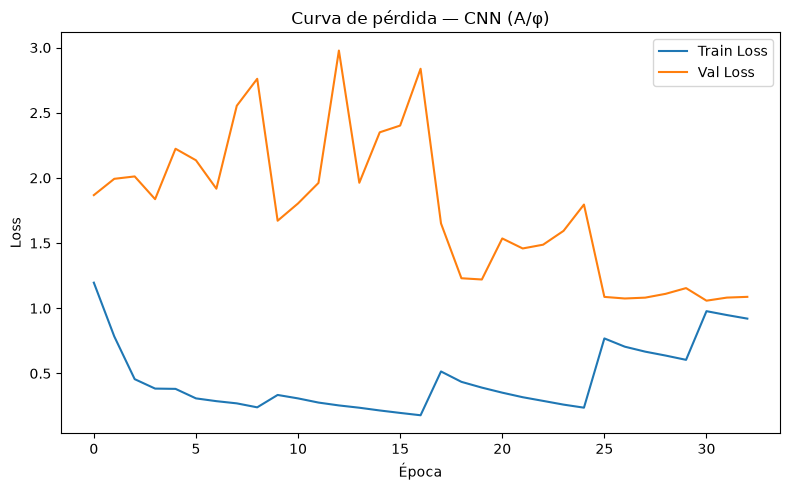

In [5]:
# Curva de pérdida
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curva de pérdida — CNN (A/\u03c6)")
plt.legend()
plt.tight_layout()
plt.savefig("curva_perdida.png", dpi=150)
plt.show()

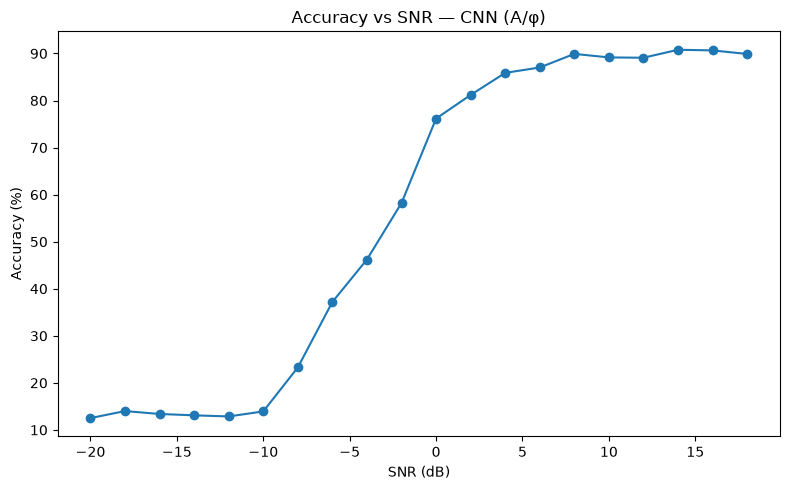

In [6]:
# Accuracy vs SNR
snr_levels = sorted(snr_acc.keys())
plt.figure(figsize=(8, 5))
plt.plot(snr_levels, [snr_acc[s] * 100 for s in snr_levels], marker="o")
plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs SNR — CNN (A/\u03c6)")
plt.tight_layout()
plt.savefig("accuracy_vs_snr.png", dpi=150)
plt.show()

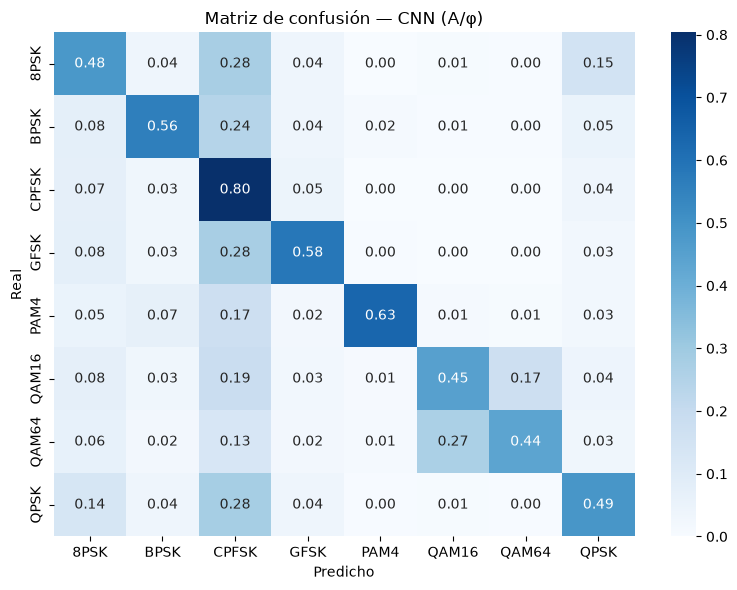

In [7]:
# Matriz de confusión (todos los SNR)
cm = compute_cm(model, X_test, y_test, device=DEVICE)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".2f", xticklabels=le.classes_, yticklabels=le.classes_,
            cmap="Blues", ax=ax)
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
ax.set_title("Matriz de confusión — CNN (A/\u03c6)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

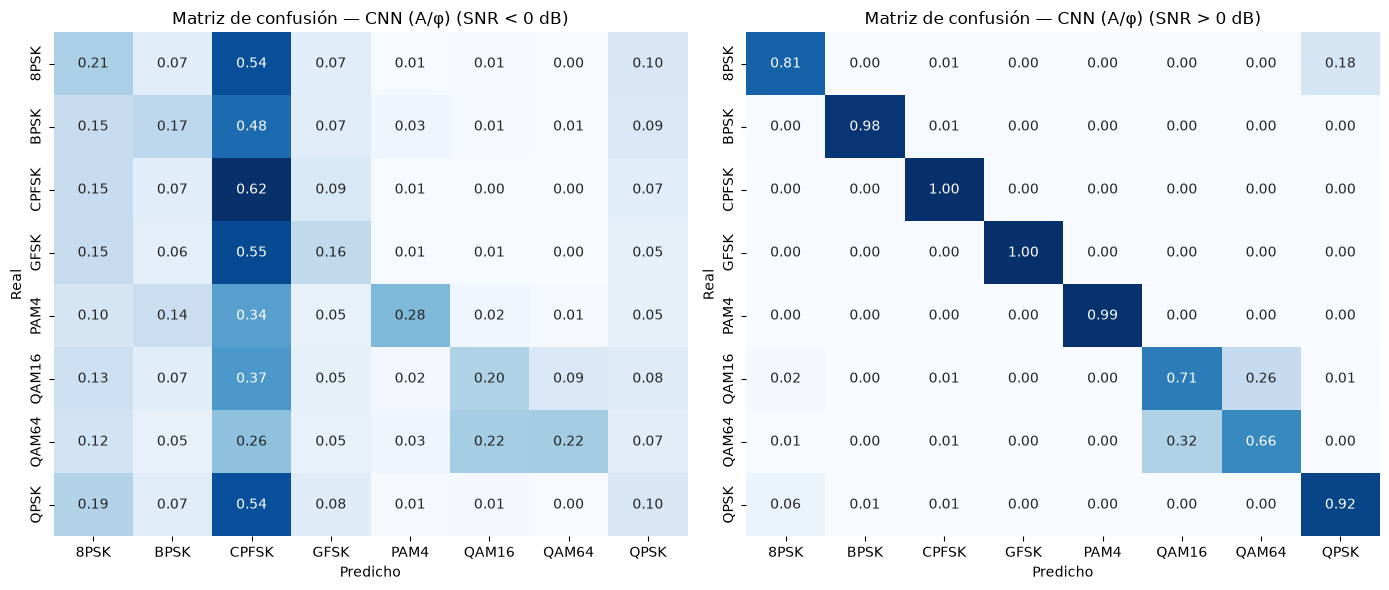

In [8]:
# Matrices de confusión por rango de SNR (bajo: <0 dB, alto: >0 dB)
mask_low = snr_test < 0
mask_high = snr_test > 0

cm_low = compute_cm(model, X_test[mask_low], y_test[mask_low], device=DEVICE)
cm_high = compute_cm(model, X_test[mask_high], y_test[mask_high], device=DEVICE)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, cm_snr, titulo in zip(axes, [cm_low, cm_high], ["SNR < 0 dB", "SNR > 0 dB"]):
    sns.heatmap(cm_snr, annot=True, fmt=".2f", xticklabels=le.classes_, yticklabels=le.classes_,
                cmap="Blues", ax=ax, cbar=False)
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
    ax.set_title(f"Matriz de confusión — CNN (A/\u03c6) ({titulo})")
plt.tight_layout()
plt.savefig("confusion_matrix_por_snr.png", dpi=150)
plt.show()

In [9]:
# --- Guardar esta corrida (no pisa nada: cada ejecución crea su propia carpeta) ---------------------
import json
from datetime import datetime
from pathlib import Path

LR = 1e-3        # lr usado en train_model(...) de este notebook (default 1e-3)
AUGMENT = True   # augment_rotate_iq aplicado en train (antes de A/φ)
SCHEDULER = False  # no se usó use_lr_scheduler
DATA_CONFIG = {"data_source": "radioml"}

_folder = globals().get("RUN_NAME", Path.cwd().name)
_ARCH = {"cnn": ("cnn", "iq"), "lstm": ("lstm", "iq"), "gru": ("gru", "iq"), "tcn": ("tcn", "iq"),
         "cnn_ap": ("cnn", "ap"), "tcn_ap": ("tcn", "ap"), "cnn_preproc": ("ulcnn", "iq")}
_arch, _repr = _ARCH.get(_folder, (_folder, "iq"))
_cur = bool(globals().get("USE_CURRICULUM", False))
_low, _pos = snr_test <= -10, snr_test > 0

_cfg = {
    "arch": _arch, "repr": _repr, "target": "notebook", "params": int(model.count_parameters()),
    "model_kwargs": {k: (list(v) if isinstance(v, tuple) else v) for k, v in MODEL_KWARGS.items()},
    "lr": LR, "batch_size": BATCH_SIZE, "epochs": EPOCHS, "patience": PATIENCE,
    "augment": AUGMENT, "curriculum": _cur, "lr_scheduler": SCHEDULER,
    "curriculum_kwargs": globals().get("CURRICULUM_KWARGS") if _cur else None,
    **DATA_CONFIG, "seed": SEED, "fuente": f"notebook {_folder}", "fecha": datetime.now().isoformat(timespec="seconds"),
}
_metrics = {
    "accuracy_global": float(acc),
    "accuracy_snr_menor_igual_-10": float(overall_accuracy(model, X_test[_low], y_test[_low], device=DEVICE)),
    "accuracy_snr_mayor_0": float(overall_accuracy(model, X_test[_pos], y_test[_pos], device=DEVICE)),
    "accuracy_por_snr": {str(int(k)): float(v) for k, v in snr_acc.items()},
    "parametros": _cfg["params"],
    "epocas_entrenadas": len(history["train_loss"]),
    "mejor_val_acc": float(max(history["val_acc"])),
    "mejor_val_loss": float(min(history["val_loss"])),
    "segundos_entrenamiento": 0.0,  # el notebook no mide el tiempo
}

_rid = (f"{_arch}_{_repr}_p{_cfg['params']}_lr{LR:g}_bs{BATCH_SIZE}_aug{int(AUGMENT)}_cur{int(_cur)}{'_sch' if SCHEDULER else ''}"
        f"_seed{SEED}_nb{datetime.now():%Y%m%d-%H%M%S}")
_out = Path(globals().get("SWEEP_DIR", Path.cwd().resolve().parents[1] / "Resultados" / "sweep")) / _rid
_out.mkdir(parents=True, exist_ok=False)  # falla en vez de pisar si ya existiera
(_out / "config.json").write_text(json.dumps(_cfg, indent=2, ensure_ascii=False), encoding="utf-8")
(_out / "history.json").write_text(json.dumps(
    {k: [float(x) for x in v] for k, v in history.items() if isinstance(v, list)}), encoding="utf-8")
torch.save(model.state_dict(), _out / "model.pt")
(_out / "metrics.json").write_text(json.dumps(_metrics, indent=2), encoding="utf-8")  # marca de "terminada"
print(f"Corrida guardada en {_out}")

Corrida guardada en D:\CEIA\Proyecto_AMC\Resultados\sweep\cnn_ap_p1063048_lr0.001_bs256_aug1_cur1_seed42_nb20261003-113223
